# 03 — Publication Figures: the peak-timing finding

**Purpose.** Turn the headline Week-3 result — *Tet search interest peaks 1–2 weeks before Mung 1,
not the four weeks the planner heuristic assumes* — into clean, reusable figures for the white
paper and the LinkedIn content series (Post 2).

**One figure per Tet-sensitive category, two renders each:**
- a **white-paper** version (large landscape, fully annotated) -> `output/whitepaper/figures/`
- a **LinkedIn** version (4:5 portrait, mobile-readable, one headline) -> `output/linkedin/`

**Categories.** Only the three categories with a real Tet peak — `banh_keo` (confectionery),
`bia` (beer), `nuoc_ngot` (soft drinks). `dau_an` and `sua` have **no Tet spike** (see
`01_eda.ipynb`), so "peak timing" is undefined for them; they are out of scope for this figure set.

**Numbers come from the baseline comparison in `01_eda.ipynb`** (§4.1–§4.4 of
`docs/methodology.md`) — scale-invariant under per-file normalization. The STL notebook (`02`) is
not a number source. Every chart shows **uplift relative to the within-year baseline**, never a
raw search-index level (`docs/methodology.md` §4.6), and every finding is **search-implied**, not
sales (§5).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from pathlib import Path

ROOT = Path('..').resolve()

df = pd.read_csv(ROOT / 'data' / 'processed' / 'trends_long.csv')
df['week_start'] = pd.to_datetime(df['week_start'])
df = df[df['week_start'].dt.year == df['year']].copy()   # year-boundary dedup (methodology 4.6)

tet_dates = {
    2020: pd.Timestamp('2020-01-25'), 2021: pd.Timestamp('2021-02-12'),
    2022: pd.Timestamp('2022-02-01'), 2023: pd.Timestamp('2023-01-22'),
    2024: pd.Timestamp('2024-02-10'), 2025: pd.Timestamp('2025-01-29'),
}

KEYWORDS = ['banh_keo', 'bia', 'nuoc_ngot']
LABELS = {
    'banh_keo':  'Banh keo (Confectionery)',
    'bia':       'Bia (Beer)',
    'nuoc_ngot': 'Nuoc ngot (Soft drinks)',
}
# Per-category headline for the LinkedIn render (the Post-2 hook).
HEADLINES = {
    'banh_keo':  'Confectionery search peaks 1-2 weeks before Tet -\nnot the 4 weeks planners assume.',
    'bia':       'Beer peaks just before Tet - and stays elevated\nright through the holiday week itself.',
    'nuoc_ngot': 'Soft-drink search peaks ~1 week before Tet,\nthen drops straight back to normal.',
}

WP_DIR = ROOT / 'output' / 'whitepaper' / 'figures'
LI_DIR = ROOT / 'output' / 'linkedin'
WP_DIR.mkdir(parents=True, exist_ok=True)
LI_DIR.mkdir(parents=True, exist_ok=True)
print('Output dirs ready:', WP_DIR.relative_to(ROOT), '|', LI_DIR.relative_to(ROOT))

Output dirs ready: output\whitepaper\figures | output\linkedin


## Baseline metrics + Tet-aligned profile

Two computations, both straight from the §4 baseline definitions:

1. **`category_metrics`** reproduces the four `01_eda` metrics (pre-Tet uplift %, peak uplift %,
   peak timing in weeks-before-Tet, holiday dip %) per `(category, year)`, then averages across
   the six years. These supply every annotated **number**.
2. **`aligned_profile`** superposes the six years on a common axis of *weeks relative to Mung 1*
   (T-8 .. T+4) and averages each year's `search_index / that-year-baseline-mean`. This is the
   classic superposed-epoch view; it supplies the **curve**. Because each year is divided by its
   own baseline before averaging, the profile is in baseline-relative units and stays
   scale-invariant under per-file normalization.

In [2]:
BUILD_UP_WEEKS = 6   # pre-Tet build-up window, methodology 3
RECOVERY_WEEKS = 4   # post-Tet recovery window, methodology 3

def _baseline_mean(g, t):
    base = g[(g.week_start < t - pd.Timedelta(weeks=BUILD_UP_WEEKS))
             | (g.week_start >= t + pd.Timedelta(weeks=RECOVERY_WEEKS))]
    return base.search_index.mean()

def category_metrics(keyword):
    """Mean of the four 01_eda baseline metrics across the six years."""
    rows = []
    for yr, g in df[df.keyword == keyword].groupby('year'):
        t = tet_dates[yr]
        bm = _baseline_mean(g, t)
        pre = g[(g.week_start >= t - pd.Timedelta(weeks=BUILD_UP_WEEKS)) & (g.week_start < t)]
        hol = g[(g.week_start >= t) & (g.week_start < t + pd.Timedelta(days=8))]
        peak_week = pre.loc[pre.search_index.idxmax(), 'week_start']
        rows.append({
            'pre_tet_uplift': (pre.search_index.mean() / bm - 1) * 100,
            'peak_uplift':    (pre.search_index.max() / bm - 1) * 100,
            'peak_tminus_wk': (t - peak_week).days / 7,
            'holiday_dip':    (hol.search_index.mean() / bm - 1) * 100,
        })
    return pd.DataFrame(rows).mean()

def aligned_profile(keyword):
    """Per-year and mean uplift% curves on a weeks-relative-to-Tet axis (T-8..T+4)."""
    per_year, peaks = {}, []
    for yr, g in df[df.keyword == keyword].groupby('year'):
        t = tet_dates[yr]
        bm = _baseline_mean(g, t)
        w = g[(g.week_start >= t - pd.Timedelta(weeks=8))
              & (g.week_start <= t + pd.Timedelta(weeks=RECOVERY_WEEKS))].copy()
        w['rel'] = ((w.week_start - t).dt.days / 7).round().astype(int)
        w['uplift'] = (w.search_index / bm - 1) * 100
        per_year[yr] = w.set_index('rel')['uplift']
        pre = w[(w.rel >= -BUILD_UP_WEEKS) & (w.rel < 0)]
        pk = pre.loc[pre.uplift.idxmax()]   # row of this year's pre-Tet peak
        peaks.append((pk['rel'], pk['uplift']))   # (weeks-relative-to-Tet, uplift%)
    mean_curve = pd.concat(per_year.values(), axis=1).mean(axis=1).sort_index()
    return per_year, mean_curve, peaks

# Assemble once, reuse for both renders.
DATA = {kw: {'m': category_metrics(kw), **dict(zip(('per_year', 'mean', 'peaks'),
                                                   aligned_profile(kw)))}
        for kw in KEYWORDS}

for kw in KEYWORDS:
    m = DATA[kw]['m']
    print(f"{kw:10s} peak +{m.peak_uplift:.0f}%  at T-{m.peak_tminus_wk:.1f}w  "
          f"pre-Tet +{m.pre_tet_uplift:.0f}%  holiday {m.holiday_dip:+.0f}%")

banh_keo   peak +130%  at T-1.4w  pre-Tet +93%  holiday -2%
bia        peak +129%  at T-0.7w  pre-Tet +73%  holiday +51%
nuoc_ngot  peak +82%  at T-1.0w  pre-Tet +37%  holiday +1%


## White-paper render (large, fully annotated)

Landscape figure per category: faint per-year curves, a bold six-year mean curve, each year's peak
marked, the build-up window shaded, Mung 1 at T=0, and the planner heuristic drawn at T-4 so the
gap between *where planners look* and *where the peak actually is* is visible at a glance.

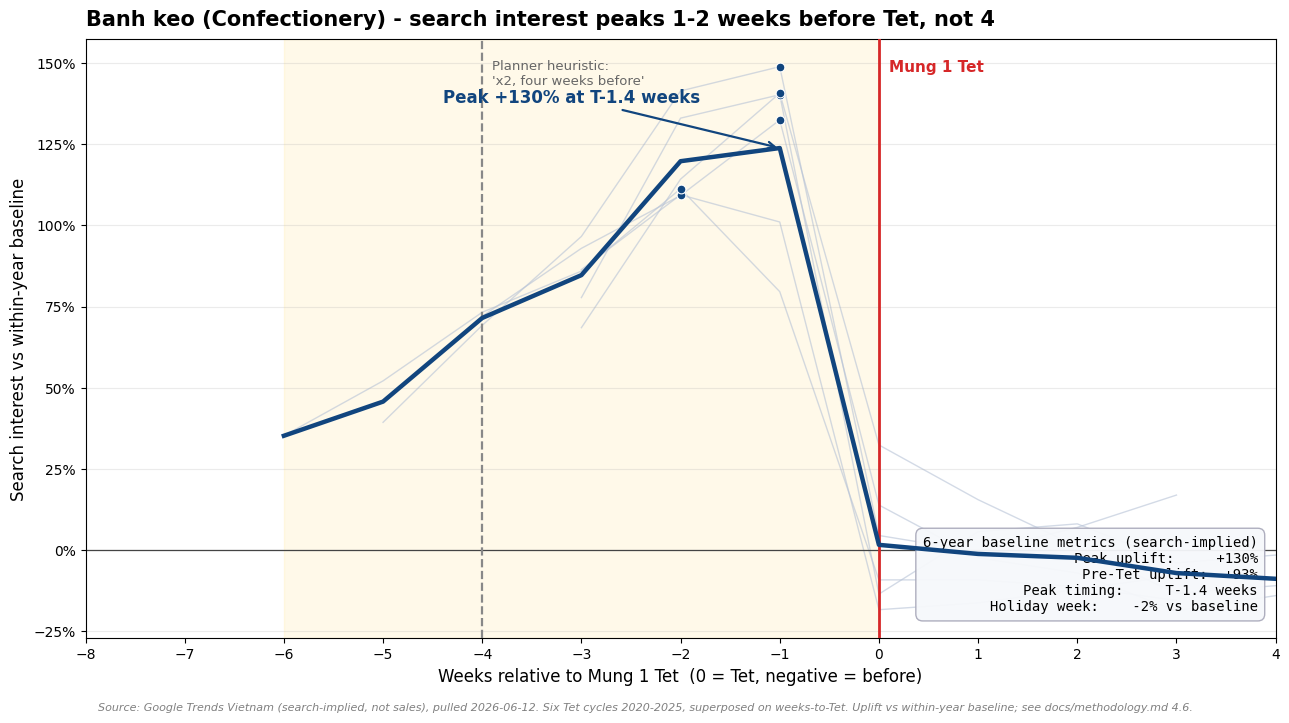

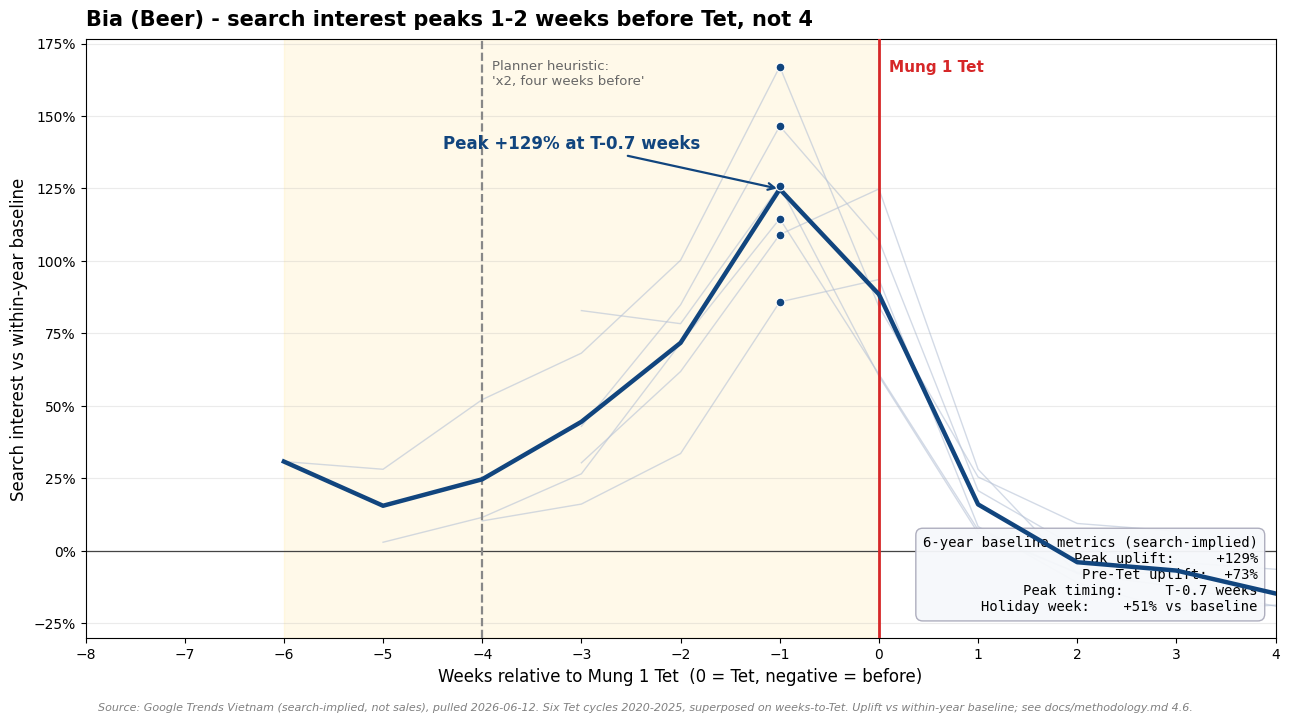

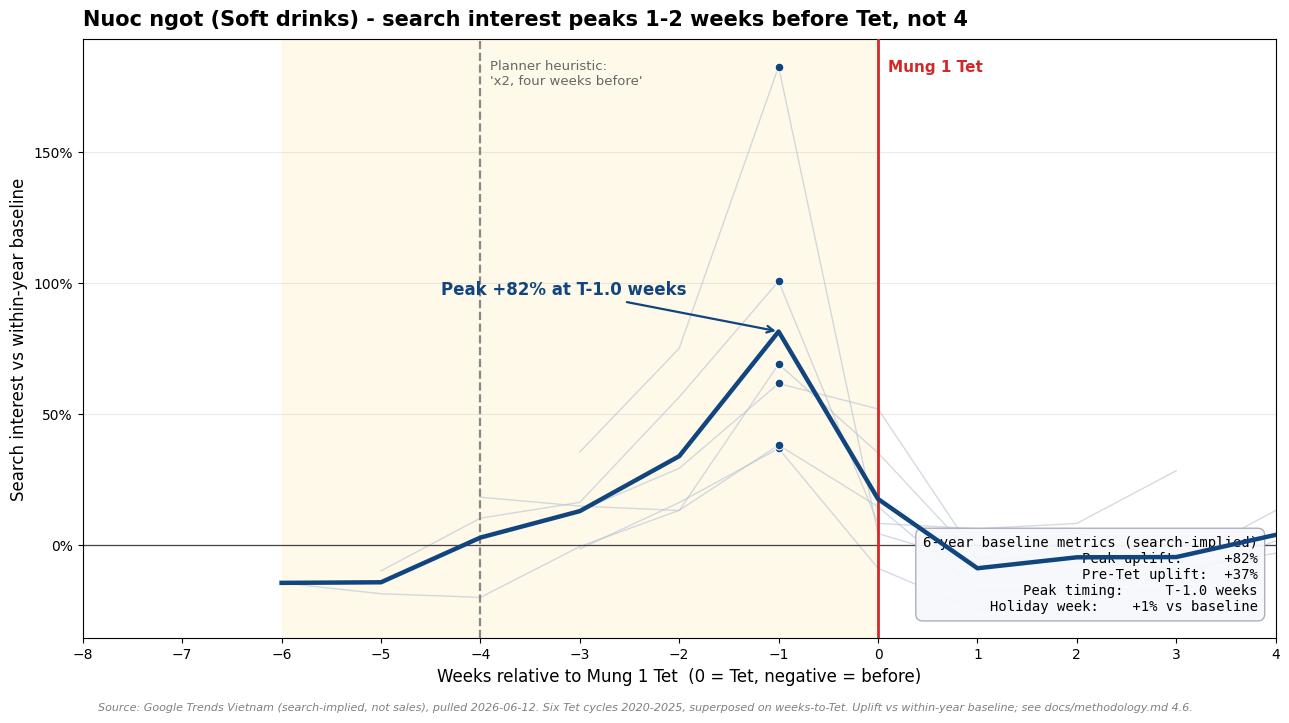

In [3]:
PLANNER_HEURISTIC_WK = -4   # 'x2 demand four weeks before Tet'
MEAN_COLOR = '#11457e'
TET_COLOR  = '#d62728'

def _draw_core(ax, kw, big):
    d = DATA[kw]
    xs = list(range(-8, RECOVERY_WEEKS + 1))
    # Per-year faint curves (reindexed onto the common axis so x and y align).
    for yr, s in d['per_year'].items():
        ax.plot(xs, s.reindex(xs).values, color='#b6c2d6',
                linewidth=1.0 if big else 0.8, alpha=0.6, zorder=1)
    # Bold six-year mean.
    ax.plot(xs, d['mean'].reindex(xs).values, color=MEAN_COLOR,
            linewidth=3.2 if big else 3.6, zorder=4, label='6-year mean')
    # Baseline (0%) and build-up shading.
    ax.axhline(0, color='#444', linewidth=0.9, zorder=2)
    ax.axvspan(-BUILD_UP_WEEKS, 0, color='#ffd34d', alpha=0.12, zorder=0)
    # Tet line and planner-heuristic line.
    ax.axvline(0, color=TET_COLOR, linewidth=2.0, zorder=3)
    ax.axvline(PLANNER_HEURISTIC_WK, color='#888', linestyle='--', linewidth=1.6, zorder=3)
    ax.yaxis.set_major_formatter(PercentFormatter())
    return d

def figure_whitepaper(kw):
    d = DATA[kw]; m = d['m']
    fig, ax = plt.subplots(figsize=(13, 7.2))
    _draw_core(ax, kw, big=True)

    # Per-year peak markers + mean-peak callout.
    for rel, up in d['peaks']:
        ax.scatter([rel], [up], s=40, color=MEAN_COLOR, edgecolor='white',
                   linewidth=0.8, zorder=5)
    peak_rel = d['mean'].idxmax(); peak_val = d['mean'].max()
    ax.annotate(
        f'Peak +{m.peak_uplift:.0f}% at T-{m.peak_tminus_wk:.1f} weeks',
        xy=(peak_rel, peak_val), xytext=(peak_rel - 3.4, peak_val + 14),
        fontsize=12, fontweight='bold', color=MEAN_COLOR,
        arrowprops=dict(arrowstyle='->', color=MEAN_COLOR, linewidth=1.6),
    )
    ax.text(0.1, ax.get_ylim()[1] * 0.96, 'Mung 1 Tet', color=TET_COLOR,
            fontsize=11, fontweight='bold', va='top')
    ax.text(PLANNER_HEURISTIC_WK + 0.1, ax.get_ylim()[1] * 0.96,
            "Planner heuristic:\n'x2, four weeks before'", color='#666',
            fontsize=9.5, va='top')

    # Metric box.
    box = (f"6-year baseline metrics (search-implied)\n"
           f"Peak uplift:     +{m.peak_uplift:.0f}%\n"
           f"Pre-Tet uplift:  +{m.pre_tet_uplift:.0f}%\n"
           f"Peak timing:     T-{m.peak_tminus_wk:.1f} weeks\n"
           f"Holiday week:    {m.holiday_dip:+.0f}% vs baseline")
    ax.text(0.985, 0.04, box, transform=ax.transAxes, fontsize=10, family='monospace',
            ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#f6f8fb', edgecolor='#aab', alpha=0.95))

    ax.set_xlim(-8, RECOVERY_WEEKS); ax.set_xticks(list(range(-8, RECOVERY_WEEKS + 1)))
    ax.set_xlabel('Weeks relative to Mung 1 Tet  (0 = Tet, negative = before)', fontsize=12)
    ax.set_ylabel('Search interest vs within-year baseline', fontsize=12)
    ax.set_title(f'{LABELS[kw]} - search interest peaks {abs(round(m.peak_tminus_wk)):.0f}'
                 f'-2 weeks before Tet, not 4',
                 fontsize=15, fontweight='bold', loc='left', pad=10)
    ax.grid(True, axis='y', alpha=0.25)
    fig.text(0.5, 0.005,
             'Source: Google Trends Vietnam (search-implied, not sales), pulled 2026-06-12. '
             'Six Tet cycles 2020-2025, superposed on weeks-to-Tet. '
             'Uplift vs within-year baseline; see docs/methodology.md 4.6.',
             ha='center', fontsize=8, style='italic', color='gray')
    plt.tight_layout(rect=[0, 0.02, 1, 1])
    fig.savefig(WP_DIR / f'peaktiming_{kw}.png', dpi=150, bbox_inches='tight')
    plt.show()

for kw in KEYWORDS:
    figure_whitepaper(kw)

## LinkedIn render (4:5 portrait, mobile-first)

Same data, stripped to what reads on a phone: the bold mean curve, the Tet line, the heuristic
line, one headline, and the single number that matters. 1080x1350 px (LinkedIn's preferred
portrait ratio).

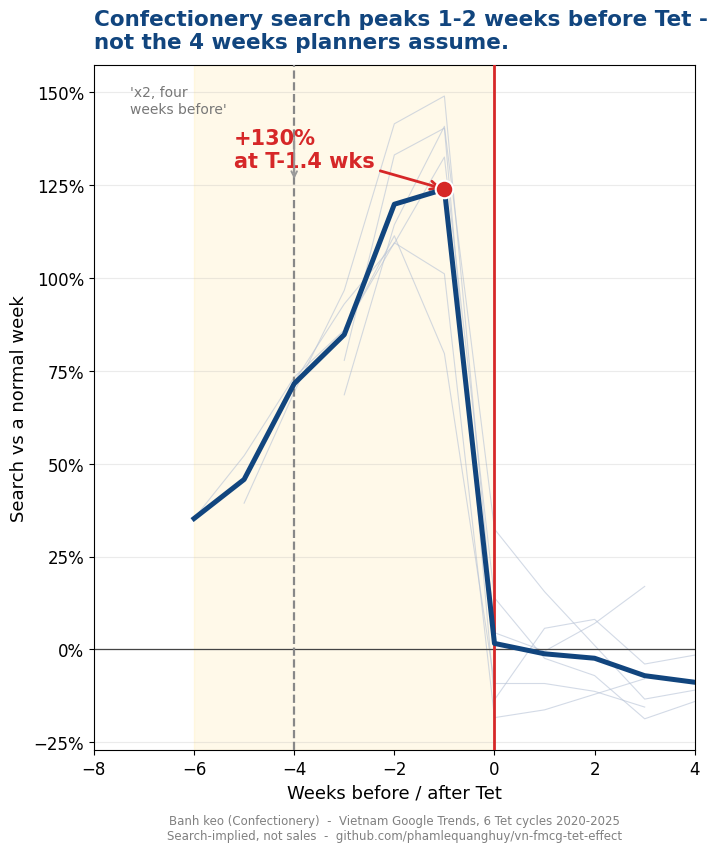

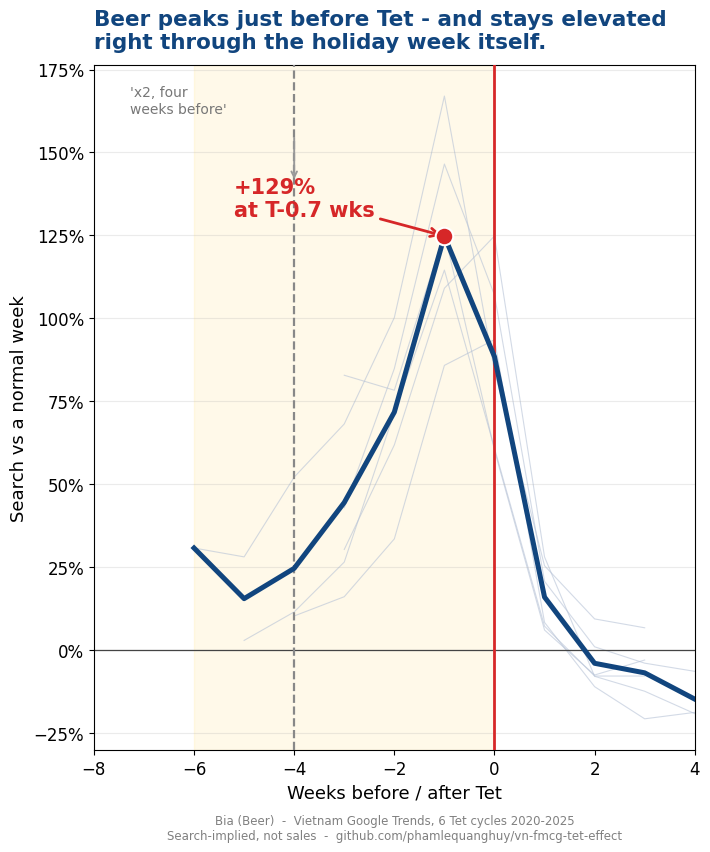

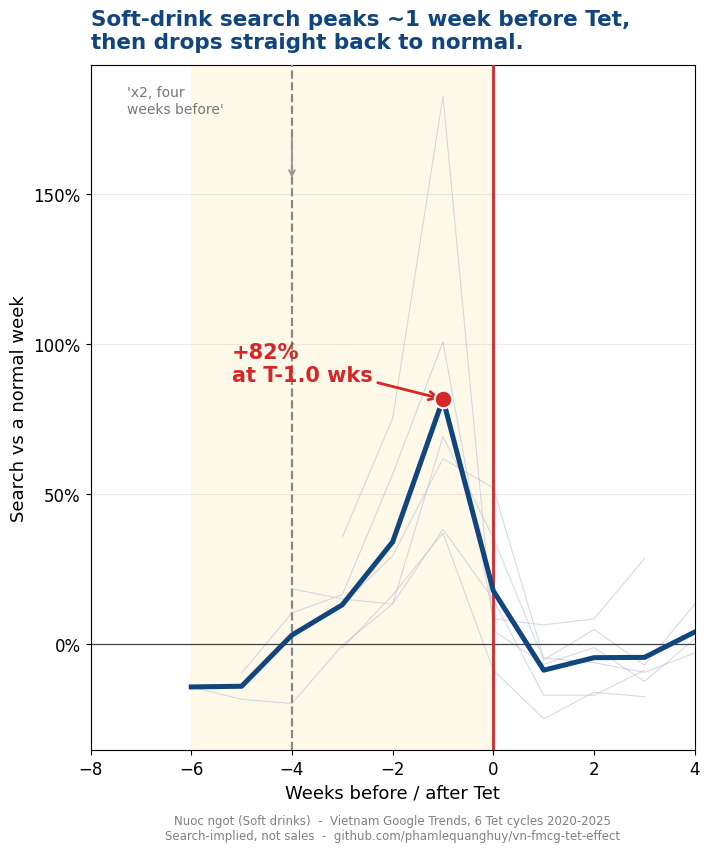

In [4]:
def figure_linkedin(kw):
    d = DATA[kw]; m = d['m']
    fig, ax = plt.subplots(figsize=(7.2, 9.0))   # 4:5 -> 1080x1350 at dpi 150
    _draw_core(ax, kw, big=False)

    peak_rel = d['mean'].idxmax(); peak_val = d['mean'].max()
    ax.scatter([peak_rel], [peak_val], s=160, color=TET_COLOR, edgecolor='white',
               linewidth=1.5, zorder=6)
    ax.annotate(f'+{m.peak_uplift:.0f}%\nat T-{m.peak_tminus_wk:.1f} wks',
                xy=(peak_rel, peak_val), xytext=(peak_rel - 4.2, peak_val + 6),
                fontsize=15, fontweight='bold', color=TET_COLOR,
                arrowprops=dict(arrowstyle='->', color=TET_COLOR, linewidth=2))

    ax.text(0.06, 0.97, "'x2, four\nweeks before'", transform=ax.transAxes,
            fontsize=10, color='#777', va='top', ha='left')
    ax.annotate('', xy=(PLANNER_HEURISTIC_WK, ax.get_ylim()[1] * 0.80),
                xytext=(PLANNER_HEURISTIC_WK, ax.get_ylim()[1] * 0.88),
                arrowprops=dict(arrowstyle='->', color='#999', linewidth=1.4))

    ax.set_xlim(-8, RECOVERY_WEEKS); ax.set_xticks([-8, -6, -4, -2, 0, 2, 4])
    ax.set_xlabel('Weeks before / after Tet', fontsize=13)
    ax.set_ylabel('Search vs a normal week', fontsize=13)
    ax.set_title(HEADLINES[kw].replace('\\n', '\n'), fontsize=15.5, fontweight='bold',
                 loc='left', pad=12, color='#11457e')
    ax.tick_params(labelsize=12)
    ax.grid(True, axis='y', alpha=0.25)
    ax.text(0.5, -0.13, f'{LABELS[kw]}  -  Vietnam Google Trends, 6 Tet cycles 2020-2025\n'
                        'Search-implied, not sales  -  github.com/phamlequanghuy/vn-fmcg-tet-effect',
            transform=ax.transAxes, ha='center', fontsize=8.5, color='gray')
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    fig.savefig(LI_DIR / f'peaktiming_{kw}.png', dpi=150, bbox_inches='tight')
    plt.show()

for kw in KEYWORDS:
    figure_linkedin(kw)

## Output summary

Six figures written:

| Category | White paper | LinkedIn |
|----------|-------------|----------|
| `banh_keo` | `output/whitepaper/figures/peaktiming_banh_keo.png` | `output/linkedin/peaktiming_banh_keo.png` |
| `bia` | `output/whitepaper/figures/peaktiming_bia.png` | `output/linkedin/peaktiming_bia.png` |
| `nuoc_ngot` | `output/whitepaper/figures/peaktiming_nuoc_ngot.png` | `output/linkedin/peaktiming_nuoc_ngot.png` |

All numbers trace to the `01_eda` baseline metrics (scale-invariant; `docs/methodology.md` §4.6),
all framed as **search-implied**. These three LinkedIn renders are the carousel material for
**Post 2** (peak-timing finding) — drafted separately, later.

In [5]:
# Verify all six files exist on disk.
for kw in KEYWORDS:
    for p in [WP_DIR / f'peaktiming_{kw}.png', LI_DIR / f'peaktiming_{kw}.png']:
        print(('OK  ' if p.exists() else 'MISSING  ') + str(p.relative_to(ROOT)))

OK  output\whitepaper\figures\peaktiming_banh_keo.png
OK  output\linkedin\peaktiming_banh_keo.png
OK  output\whitepaper\figures\peaktiming_bia.png
OK  output\linkedin\peaktiming_bia.png
OK  output\whitepaper\figures\peaktiming_nuoc_ngot.png
OK  output\linkedin\peaktiming_nuoc_ngot.png
